# 16 — THEME trading signals vs price

Notebook 15, but through the THEME lens only: every chart and the report
card run on the theme signals (`trade_signals.parquet`), each theme drawn
against its anchor ETF's price. Individual-ticker signals are notebook 15's
job.

Charts show the theme NAME (with its ETF), so a cluster of BUY arrows reads
as "the crowd is piling into uranium", not just "URA is signalled".

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
P = os.path.join(ROOT, 'data', 'processed')
PRICES_PATH = os.path.join(ROOT, 'data', 'prices', 'prices.parquet')

# window: the PIPELINE_* env vars (set by update_data.py, including its
# --start/--end overrides) win; otherwise fall back to the constants at the
# top of update_data.py. Same toggle as live vs backtest either way.
import update_data
START_DATE = os.environ.get('PIPELINE_START_DATE') or update_data.START_DATE
END_DATE = os.environ.get('PIPELINE_END_DATE')
if END_DATE is None:
    END_DATE = update_data.END_DATE
WIN_LO = pd.to_datetime(START_DATE)
WIN_HI = pd.to_datetime(END_DATE) if END_DATE else None
print('window:', WIN_LO.date(), '->', (WIN_HI.date() if WIN_HI is not None else 'LIVE (newest)'))

def clip_series(s):
    s = s[s.index >= WIN_LO]
    return s if WIN_HI is None else s[s.index <= WIN_HI]

def clip_dates(df, col):
    df = df[df[col] >= WIN_LO]
    return df if WIN_HI is None else df[df[col] <= WIN_HI]

def load_prices():
    if not os.path.exists(PRICES_PATH):
        raise FileNotFoundError('prices.parquet not found - run  python pull_bloomberg_prices.py  first.')
    px = pd.read_parquet(PRICES_PATH); px['date'] = pd.to_datetime(px['date'])
    return px

def price_series(prices, symbol):
    # daily close, then made CONTINUOUS (forward-fill weekends/holidays) so the
    # line is smooth with no gaps. Clip to the window.
    one = prices[prices['symbol'] == symbol].sort_values('date')
    s = one.set_index('date')['px_last']
    if not s.empty:
        s = s.asfreq('D').ffill()
    return clip_series(s)


# --- x-axis tick control (X_TICKS in the parameters cell) ---
# 'auto' = matplotlib decides; 'W' = a label every week; 'M' = every month.
# Weekly labels are only readable on windows up to ~6 months - use
# PLOT_LAST_DAYS to zoom in first.
import matplotlib.dates as mdates

def set_date_ticks(ax, ticks):
    if ticks == 'W':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Mondays
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    elif ticks == 'M':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

window: 2026-06-08 -> LIVE (newest)


In [2]:
HOW_MANY = 6
FREQ = 'W'        # 'W' weekly (smooth price line), 'D' daily, 'M' monthly
X_TICKS = 'auto'  # x-axis labels: 'auto', 'W' (weekly), 'M' (monthly)
PLOT_LAST_DAYS = None   # e.g. 120 = zoom to the last 120 days (None = whole window)
# --- high-conviction clustering: several same-direction signals close together
# on one symbol are ONE conviction event, not several trades ---
CLUSTER_DAYS = 10  # same-side signals within this many days merge into a cluster
CONV_MIN     = 2   # a cluster needs at least this many signals to count as
                   # HIGH CONVICTION (big arrow on the charts)
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', 200)

auto themes (most signalled): ['short_squeeze', 'energy', 'biotech_pharma', 'media_streaming', 'ev_clean_energy', 'memory']

short_squeeze (ARKK): 3 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                                            reason
 2026-06-16   SELL      4 4.263322 -5.333121    -1.000000 SELL ARKK: attention surged (z +4.26 > 2.5) + mood deteriorating (5d sentiment -1.000 < 0) + crowd leaning bearish (conviction z -5.33 < -2.5) + crowded-top divergence ACTIVE (crowd up, mood down) -> score 4/5
 2026-06-18    BUY      4 3.483082  4.030607     1.000000                                    BUY ARKK: attention surged (z +3.48 > 2.5) + mood improving (5d sentiment +1.000 > 0) + crowd leaning bullish (conviction z +4.03 > 2.5) + no crowded-top warning -> score 4/5
 2026-07-10   SE

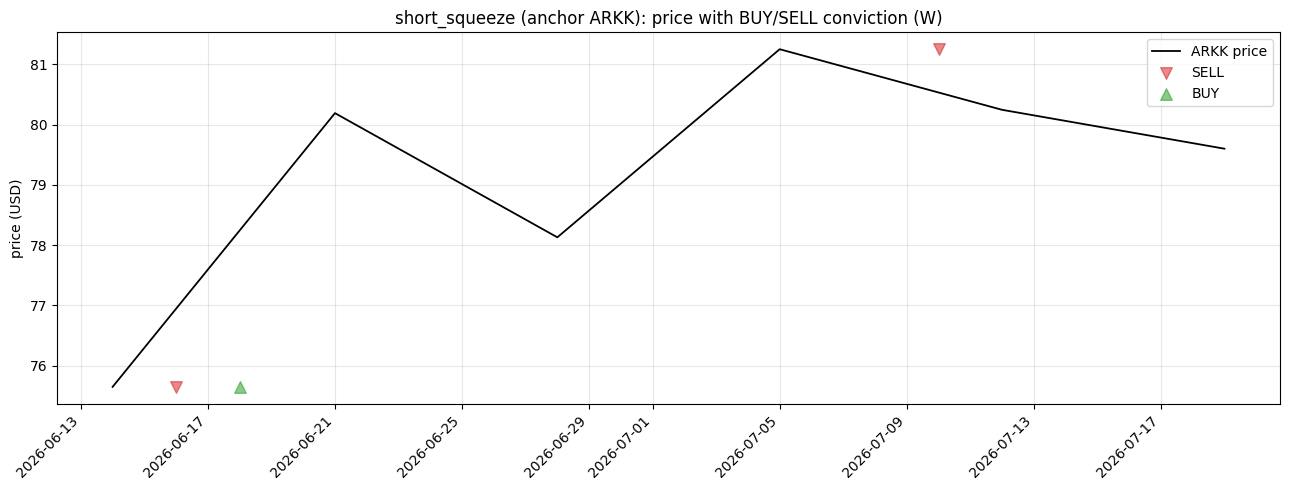


energy (XLE): 2 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                                           reason
 2026-06-20   SELL      4 2.661080 -3.238903    -1.333333 SELL XLE: attention surged (z +2.66 > 2.5) + mood deteriorating (5d sentiment -1.333 < 0) + crowd leaning bearish (conviction z -3.24 < -2.5) + crowded-top divergence ACTIVE (crowd up, mood down) -> score 4/5
 2026-07-03    BUY      4 7.014468  3.234986     0.507692                                    BUY XLE: attention surged (z +7.01 > 2.5) + mood improving (5d sentiment +0.508 > 0) + crowd leaning bullish (conviction z +3.23 > 2.5) + no crowded-top warning -> score 4/5


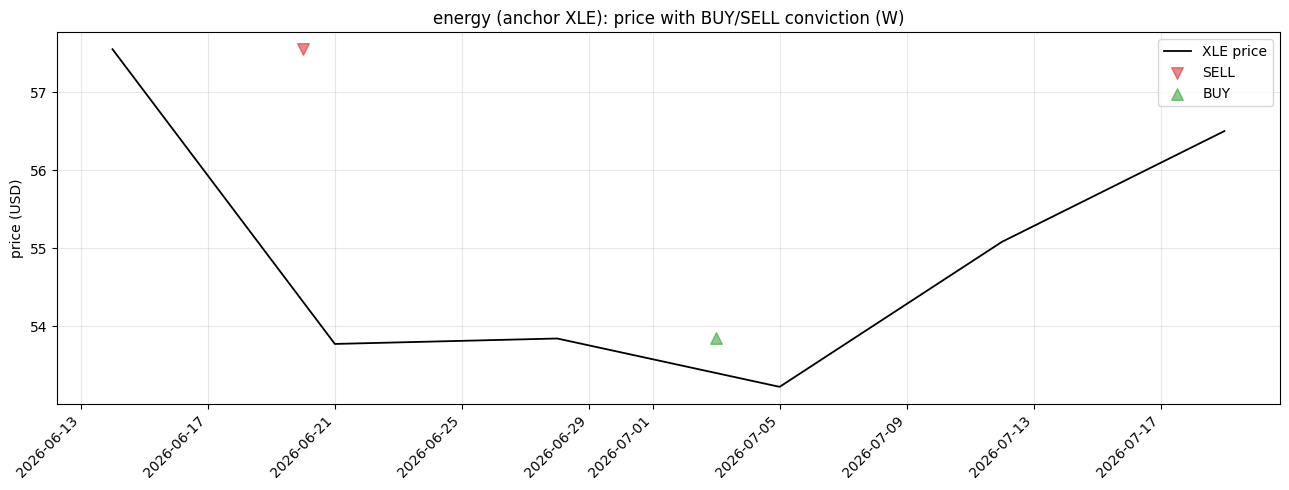


biotech_pharma (XBI): 2 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                                           reason
 2026-06-24   SELL      4 2.560734 -3.547426    -2.000000 SELL XBI: attention surged (z +2.56 > 2.5) + mood deteriorating (5d sentiment -2.000 < 0) + crowd leaning bearish (conviction z -3.55 < -2.5) + crowded-top divergence ACTIVE (crowd up, mood down) -> score 4/5
 2026-07-06    BUY      4 8.266746  6.047768     0.533333                                    BUY XBI: attention surged (z +8.27 > 2.5) + mood improving (5d sentiment +0.533 > 0) + crowd leaning bullish (conviction z +6.05 > 2.5) + no crowded-top warning -> score 4/5


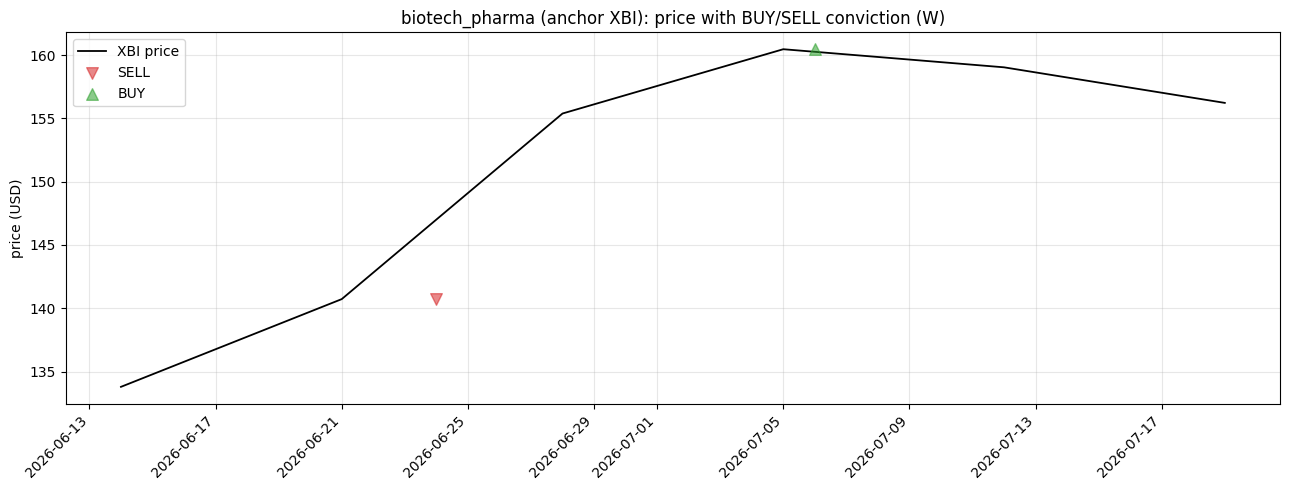


media_streaming (XLC): 2 signals - how each was decided
action_date action  score    att_z   conv_z  sent_5d_chg                                                                                                                                                                                                   reason
 2026-07-12    BUY      5 2.591046 3.990041     0.087121 BUY XLC: attention surged (z +2.59 > 2.5) + mood improving (5d sentiment +0.087 > 0) + crowd leaning bullish (conviction z +3.99 > 2.5) + no crowded-top warning + Reddit AND X both rising -> score 5/5
 2026-07-16   SELL      4 5.270480 2.490618    -0.201818                  SELL XLC: attention surged (z +5.27 > 2.5) + mood deteriorating (5d sentiment -0.202 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5


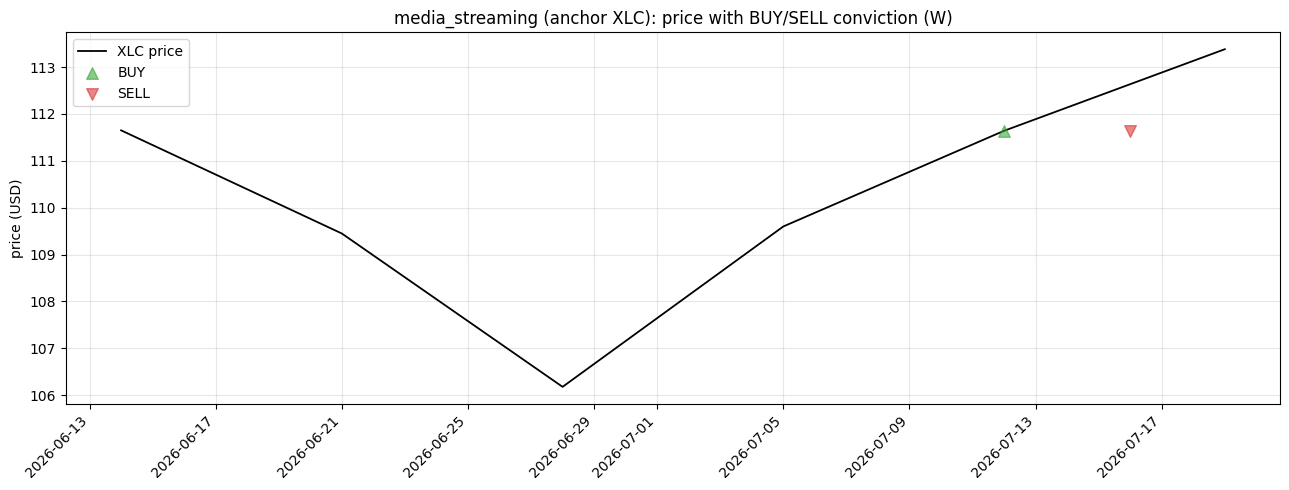


ev_clean_energy (LIT): 2 signals - how each was decided
action_date action  score    att_z   conv_z  sent_5d_chg                                                                                                                                                                                  reason
 2026-07-01    BUY      4 3.494521 4.446916     0.027778           BUY LIT: attention surged (z +3.49 > 2.5) + mood improving (5d sentiment +0.028 > 0) + crowd leaning bullish (conviction z +4.45 > 2.5) + no crowded-top warning -> score 4/5
 2026-07-08   SELL      4 6.898271 5.208571    -0.276483 SELL LIT: attention surged (z +6.90 > 2.5) + mood deteriorating (5d sentiment -0.276 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5


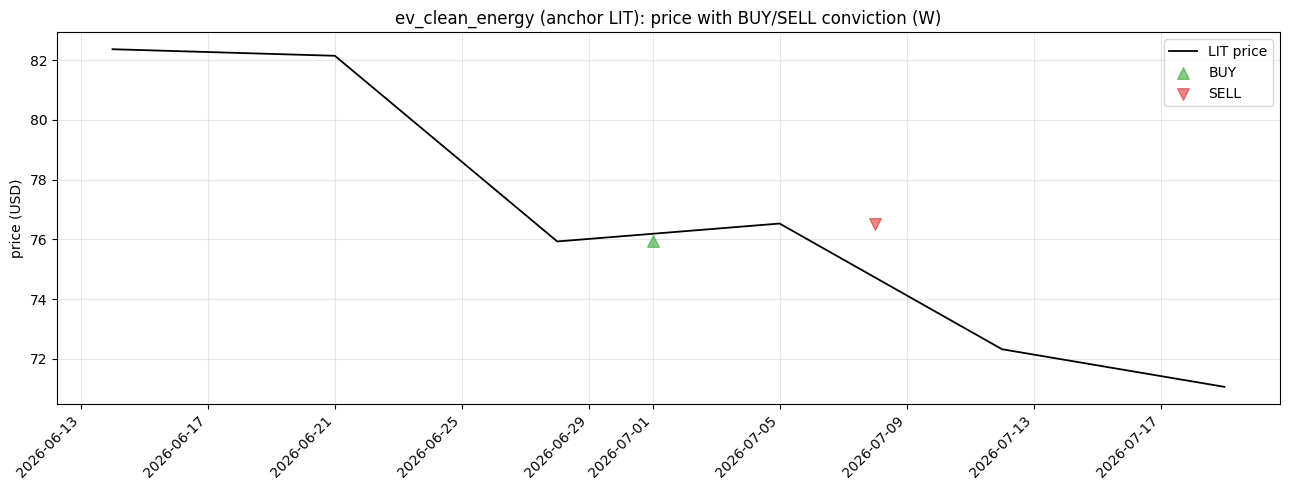


memory (SMH): 2 signals - how each was decided
action_date action  score    att_z    conv_z  sent_5d_chg                                                                                                                                                                                                           reason
 2026-06-11   SELL      4 9.056043 -3.645258    -1.000000 SELL SMH: attention surged (z +9.06 > 2.5) + mood deteriorating (5d sentiment -1.000 < 0) + crowd leaning bearish (conviction z -3.65 < -2.5) + crowded-top divergence ACTIVE (crowd up, mood down) -> score 4/5
 2026-07-02    BUY      4 2.740220  5.626207     0.239234                                    BUY SMH: attention surged (z +2.74 > 2.5) + mood improving (5d sentiment +0.239 > 0) + crowd leaning bullish (conviction z +5.63 > 2.5) + no crowded-top warning -> score 4/5
  note: signal 2026-06-11 is outside the price data span - rerun pull_bloomberg_prices.py to see it on the chart


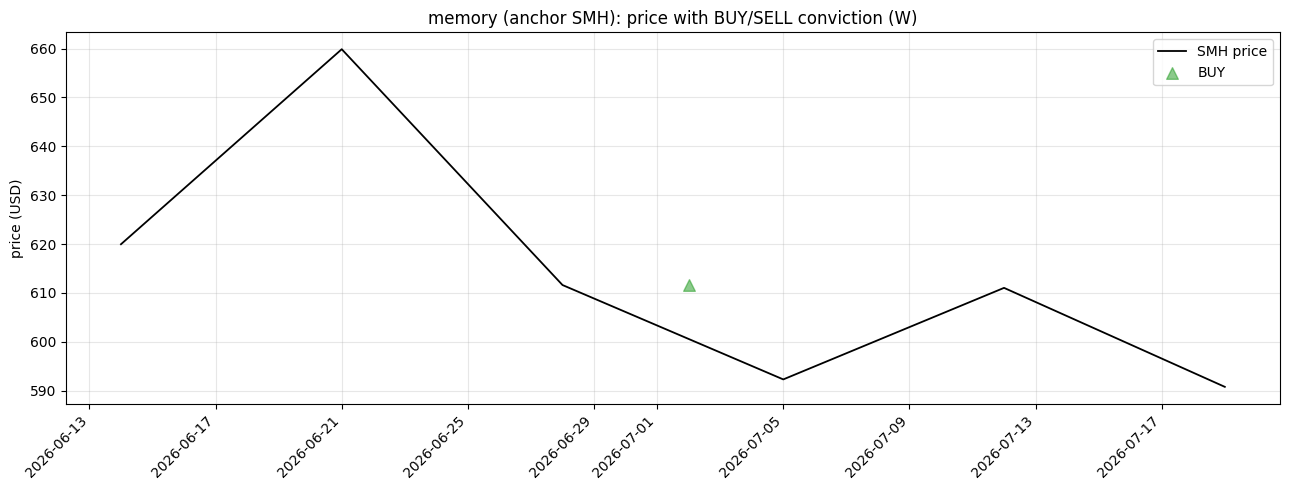

In [3]:
theme = pd.read_parquet(os.path.join(P, 'trade_signals.parquet'))
theme['action_date'] = pd.to_datetime(theme['action_date'])
theme = clip_dates(theme, 'action_date')
if PLOT_LAST_DAYS and len(theme):                    # zoom: recent stretch only
    WIN_LO = max(WIN_LO, theme['action_date'].max() - pd.Timedelta(days=PLOT_LAST_DAYS))
    theme = theme[theme['action_date'] >= WIN_LO]

# THEMES ONLY here: symbol = the theme's anchor ETF, but the theme name is
# kept for titles/tables so the charts read as trades on ideas, not tickers.
DET = ['action_date', 'action', 'score', 'att_z', 'conv_z', 'sent_5d_chg', 'reason']
sig_all = theme.rename(columns={'etf': 'symbol'})[['symbol', 'theme'] + DET]
themes_ranked = sig_all['theme'].value_counts().head(HOW_MANY).index.tolist()
print('auto themes (most signalled):', themes_ranked)

prices = load_prices()

def cluster_signals(one_symbol_df, max_gap_days=CLUSTER_DAYS):
    """Group SAME-SIDE signals whose neighbour is within max_gap_days.
    Several signals close together = the model repeating itself = one
    HIGH-CONVICTION event, not several separate trades."""
    clusters = []
    for side in ('BUY', 'SELL'):
        rows = one_symbol_df[one_symbol_df['action'] == side].sort_values('action_date')
        dates = list(rows['action_date'])
        if not dates:
            continue
        cur = [dates[0]]
        for dt in dates[1:]:
            if (dt - cur[-1]).days <= max_gap_days:
                cur.append(dt)
            else:
                clusters.append({'side': side, 'dates': cur, 'n': len(cur),
                                 'start': cur[0], 'end': cur[-1]})
                cur = [dt]
        clusters.append({'side': side, 'dates': cur, 'n': len(cur),
                         'start': cur[0], 'end': cur[-1]})
    return sorted(clusters, key=lambda c: c['start'])

for theme_name in themes_ranked:
    s = sig_all[sig_all['theme'] == theme_name]
    symbol = s['symbol'].iloc[0]
    px_daily = price_series(prices, symbol)
    if px_daily.empty:
        print('skip', theme_name, f'- no price rows for {symbol} - re-run pull_bloomberg_prices.py')
        continue

    # --- the decision detail for this theme ---
    print('\n' + '=' * 90)
    print(f'{theme_name} ({symbol}): {len(s)} signals - how each was decided')
    print('=' * 90)
    print(s[DET].to_string(index=False))

    # --- the chart ---
    px_line = px_daily if FREQ == 'D' else px_daily.resample(FREQ).last()
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(px_line.index, px_line.values, color='black', linewidth=1.3, label=f'{symbol} price')
    clusters = cluster_signals(s)
    done_labels = set()
    for cl in clusters:
        mid = cl['dates'][len(cl['dates']) // 2]           # middle of the cluster
        if px_line.empty or not (px_line.index.min() <= mid <= px_line.index.max()):
            print(f'  note: signal {mid.date()} is outside the price data span - '
                  'rerun pull_bloomberg_prices.py to see it on the chart')
            continue
        price_at = px_line.asof(mid)
        if pd.isna(price_at):
            continue
        color = 'tab:green' if cl['side'] == 'BUY' else 'tab:red'
        marker = '^' if cl['side'] == 'BUY' else 'v'
        if cl['n'] >= CONV_MIN:
            size = min(200 + 180 * (cl['n'] - CONV_MIN + 1), 900)
            label = f"HIGH CONVICTION {cl['side']}" if f"hc{cl['side']}" not in done_labels else None
            done_labels.add(f"hc{cl['side']}")
            ax.scatter([mid], [price_at], marker=marker, s=size, color=color,
                       edgecolors='black', linewidths=1.5, zorder=6, label=label)
            ax.annotate(f"x{cl['n']}", (mid, price_at), textcoords='offset points',
                        xytext=(0, 14 if cl['side'] == 'BUY' else -20),
                        fontsize=11, fontweight='bold', ha='center', color=color)
        else:
            label = cl['side'] if cl['side'] not in done_labels else None
            done_labels.add(cl['side'])
            ax.scatter([mid], [price_at], marker=marker, s=70, color=color,
                       alpha=0.55, zorder=5, label=label)
    ax.set_ylabel('price (USD)')
    ax.set_title(f'{theme_name} (anchor {symbol}): price with BUY/SELL conviction ({FREQ})')
    set_date_ticks(ax, X_TICKS)
    ax.legend(); ax.grid(True, alpha=0.3); fig.tight_layout(); plt.show()

## Signal report card — does the model work?

Three views over EVERY signal in the window (not just the top symbols above):

1. **Forward returns** — average price move 5/10/20 days AFTER acting on a
   signal. BUYs should skew positive, SELLs negative. This is the visual
   check: change the window in `update_data.py`, re-run, and compare eras.
2. **Score vs outcome** — do 5/5-score signals really beat 4/5? If yes,
   raising `MIN_SCORE` in notebook 10 is free selectivity.
3. **Signal frequency** — how many calls per week the model makes. Spikes =
   hot regimes; a flood of signals is a reason to tighten the knobs.

26 signals with price data (of 28 total)
BUY :  15 signals | 20d hit rate   53% | avg 20d return +0.66%
SELL:  10 signals | 20d hit rate   40% | avg 20d return +0.86%


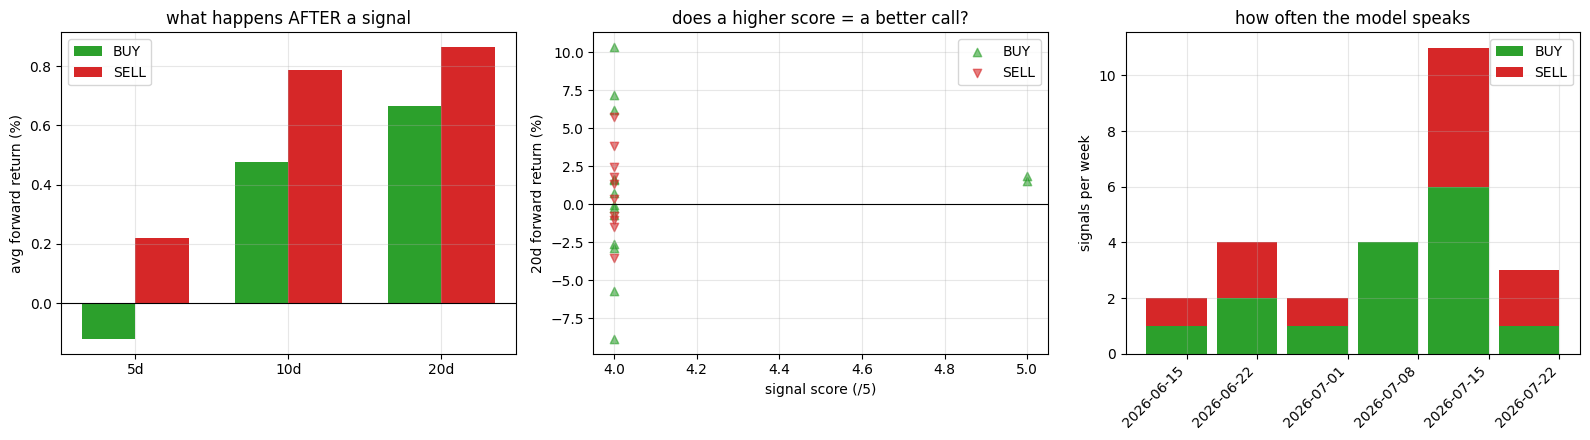

In [4]:
# ==== SIGNAL REPORT CARD ====
HORIZONS = [5, 10, 20]          # trading-day-ish horizons (calendar days, ffilled)

# price series once per symbol (they are ffilled daily, so .asof works cleanly)
px_cache = {sym: price_series(prices, sym) for sym in sig_all['symbol'].unique()}

rows = []
for _, s in sig_all.iterrows():
    px = px_cache.get(s['symbol'], pd.Series(dtype=float))
    if px.empty:
        continue
    p0 = px.asof(s['action_date'])
    if pd.isna(p0):
        continue
    row = {'symbol': s['symbol'], 'action': s['action'],
           'score': int(s['score']), 'action_date': s['action_date']}
    for h in HORIZONS:
        p1 = px.asof(s['action_date'] + pd.Timedelta(days=h))
        # signals too close to the end of the data have no forward price yet
        row[f'ret_{h}d'] = (p1 / p0 - 1) * 100 if pd.notna(p1) and p1 != p0 else None
    rows.append(row)
perf = pd.DataFrame(rows)
print(f'{len(perf)} signals with price data (of {len(sig_all)} total)')

if len(perf):
    # --- hit rate: BUYs that went up, SELLs that went down (20d horizon) ---
    for side, good in [('BUY', 1), ('SELL', -1)]:
        r = perf[perf['action'] == side]['ret_20d'].dropna()
        if len(r):
            hits = (r * good > 0).mean() * 100
            print(f'{side:<4}: {len(r):>3} signals | 20d hit rate {hits:4.0f}% '
                  f'| avg 20d return {r.mean():+.2f}%')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1. average forward return by side and horizon
    ax = axes[0]
    width = 0.35
    xs = range(len(HORIZONS))
    for off, (side, color) in enumerate([('BUY', 'tab:green'), ('SELL', 'tab:red')]):
        means = [perf[perf['action'] == side][f'ret_{h}d'].mean() for h in HORIZONS]
        ax.bar([x + off * width for x in xs], means, width, label=side, color=color)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks([x + width / 2 for x in xs])
    ax.set_xticklabels([f'{h}d' for h in HORIZONS])
    ax.set_ylabel('avg forward return (%)')
    ax.set_title('what happens AFTER a signal')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 2. score vs 20-day outcome
    ax = axes[1]
    for side, color, marker in [('BUY', 'tab:green', '^'), ('SELL', 'tab:red', 'v')]:
        sub = perf[perf['action'] == side].dropna(subset=['ret_20d'])
        ax.scatter(sub['score'], sub['ret_20d'], color=color, marker=marker,
                   alpha=0.6, label=side)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('signal score (/5)'); ax.set_ylabel('20d forward return (%)')
    ax.set_title('does a higher score = a better call?')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 3. signals per week over time
    ax = axes[2]
    weekly = (perf.set_index('action_date').groupby('action')
              .resample('W').size().unstack(0, fill_value=0) if len(perf) else None)
    if weekly is not None and len(weekly):
        if 'BUY' in weekly:
            ax.bar(weekly.index, weekly['BUY'], width=6, color='tab:green', label='BUY')
        if 'SELL' in weekly:
            ax.bar(weekly.index, weekly.get('SELL', 0), width=6, color='tab:red',
                   bottom=weekly.get('BUY', 0), label='SELL')
    ax.set_ylabel('signals per week'); ax.set_title('how often the model speaks')
    set_date_ticks(ax, X_TICKS)
    ax.legend(); ax.grid(True, alpha=0.3)

    fig.tight_layout(); plt.show()
else:
    print('no signals with price coverage in this window - '
          'run update_data.py / pull_bloomberg_prices.py first')

## The 1-week lookback — the live trading table

This is the primary trading metric. For every theme, compare the
**last 7 days** against the 7 days before:

- `velocity_chg` — mentions last 7d minus prior 7d (is attention accelerating?)
- `conv_now` — latest conviction_z (the 7-day bull-pressure z from notebook 09)
- `conv_chg_7d` — conviction now minus one week ago (is the crowd getting MORE convinced?)

Big positive `velocity_chg` + rising `conv_chg_7d` = the setup the BUY signals look for.

1-WEEK LOOKBACK (data through 2026-07-16) - sorted by attention change
                     mentions_7d  mentions_prior7d  velocity_chg  conv_now  conv_week_ago  conv_chg_7d
theme                                                                                                 
ai                           544             332.0         212.0      3.74           1.72         2.02
auto_whatsapp                209               5.0         204.0     22.27           0.24        22.03
auto_whatsapp_group          202               5.0         197.0     37.56           0.87        36.70
auto_nickkunze2              122               0.0         122.0     44.40          -0.03        44.43
financials                   230             123.0         107.0     -0.68          -0.87         0.19
rates_bonds                  283             179.0         104.0     -0.36          -0.24        -0.13
consumer_retail              316             229.0          87.0     -0.31          -0.41         0.10
fi

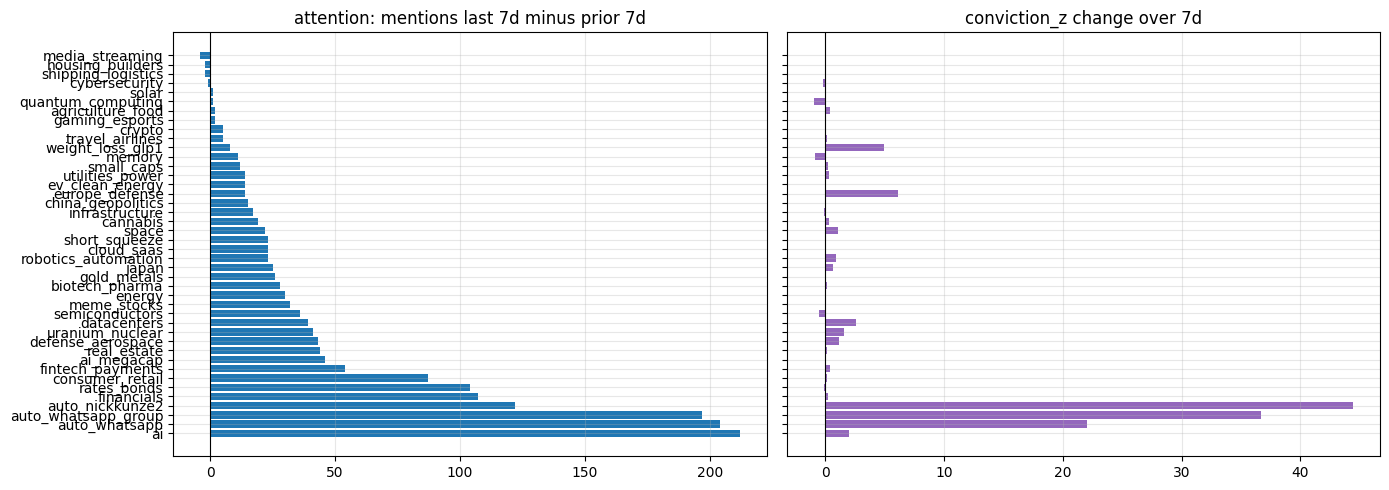

In [5]:
# ==== LIVE 1-WEEK LOOKBACK - the trading table ====
counts = pd.read_parquet(os.path.join(P, 'daily_theme_counts.parquet'))
# the aggregates carry 'mention_count'; older notebook-04 output carries
# keyword/inferred columns instead - handle both so this never breaks
if 'mention_count' not in counts.columns:
    counts['mention_count'] = (counts.get('keyword_count', 0)
                               + counts.get('inferred_count', 0))
counts['date'] = pd.to_datetime(counts['date'])
counts = clip_dates(counts, 'date')
end = counts['date'].max()

last7 = counts[counts['date'] > end - pd.Timedelta(days=7)]
prior7 = counts[(counts['date'] <= end - pd.Timedelta(days=7))
                & (counts['date'] > end - pd.Timedelta(days=14))]
tbl = pd.concat([
    last7.groupby('theme')['mention_count'].sum().rename('mentions_7d'),
    prior7.groupby('theme')['mention_count'].sum().rename('mentions_prior7d'),
], axis=1).fillna(0)
tbl['velocity_chg'] = tbl['mentions_7d'] - tbl['mentions_prior7d']

conv = pd.read_parquet(os.path.join(P, 'daily_theme_conviction.parquet'))
conv['date'] = pd.to_datetime(conv['date'])
conv = clip_dates(conv, 'date')
latest = conv.sort_values('date').groupby('theme')['conviction_z'].last().rename('conv_now')
week_ago = (conv[conv['date'] <= end - pd.Timedelta(days=7)].sort_values('date')
            .groupby('theme')['conviction_z'].last().rename('conv_week_ago'))
tbl = tbl.join(latest).join(week_ago)
tbl['conv_chg_7d'] = tbl['conv_now'] - tbl['conv_week_ago']
tbl = tbl.sort_values('velocity_chg', ascending=False).round(2)

print(f'1-WEEK LOOKBACK (data through {end.date()}) - sorted by attention change')
print(tbl.to_string())

# visual: attention change vs conviction change, one bar pair per theme
plot = tbl.dropna(subset=['conv_chg_7d'])
if len(plot):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    ax1.barh(plot.index, plot['velocity_chg'], color='tab:blue')
    ax1.set_title('attention: mentions last 7d minus prior 7d')
    ax1.axvline(0, color='black', linewidth=0.8); ax1.grid(True, alpha=0.3)
    ax2.barh(plot.index, plot['conv_chg_7d'], color='tab:purple')
    ax2.set_title('conviction_z change over 7d')
    ax2.axvline(0, color='black', linewidth=0.8); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()
else:
    print('(not enough recent data for the chart - run update_data.py in LIVE mode first)')

## Signal components: WHAT fired each BUY/SELL

For each theme above: price with the signal triangles (top) and the exact
ingredients notebook 10 weighed (bottom) - attention z (crowd size),
conviction z (crowd size x bullish lean), both against TRAILING 84-day
baselines exactly as the signal generator computes them, plus the 5-day
sentiment change on the right axis. Dashed lines mark +/-K, the trigger
threshold. Vertical bands mark the signal dates - trace any triangle down
to see which ingredient(s) crossed.

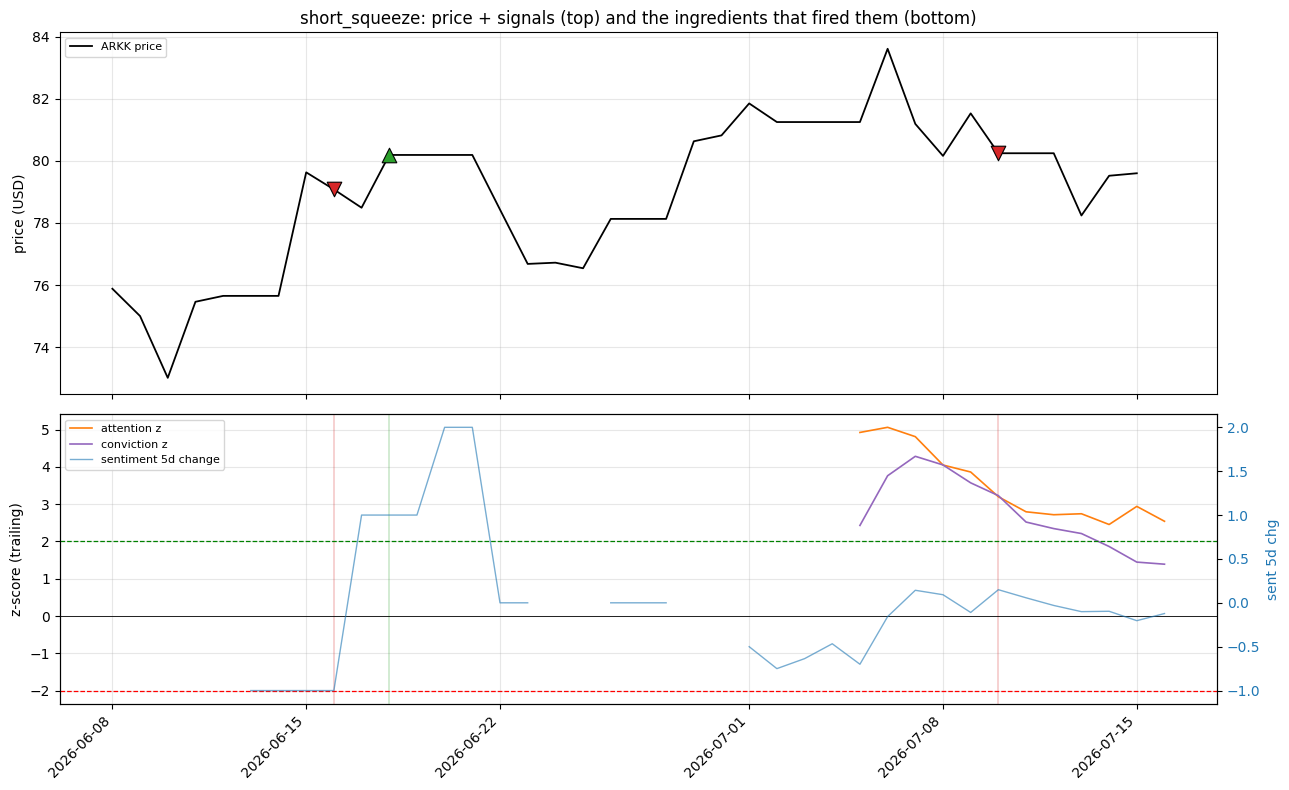

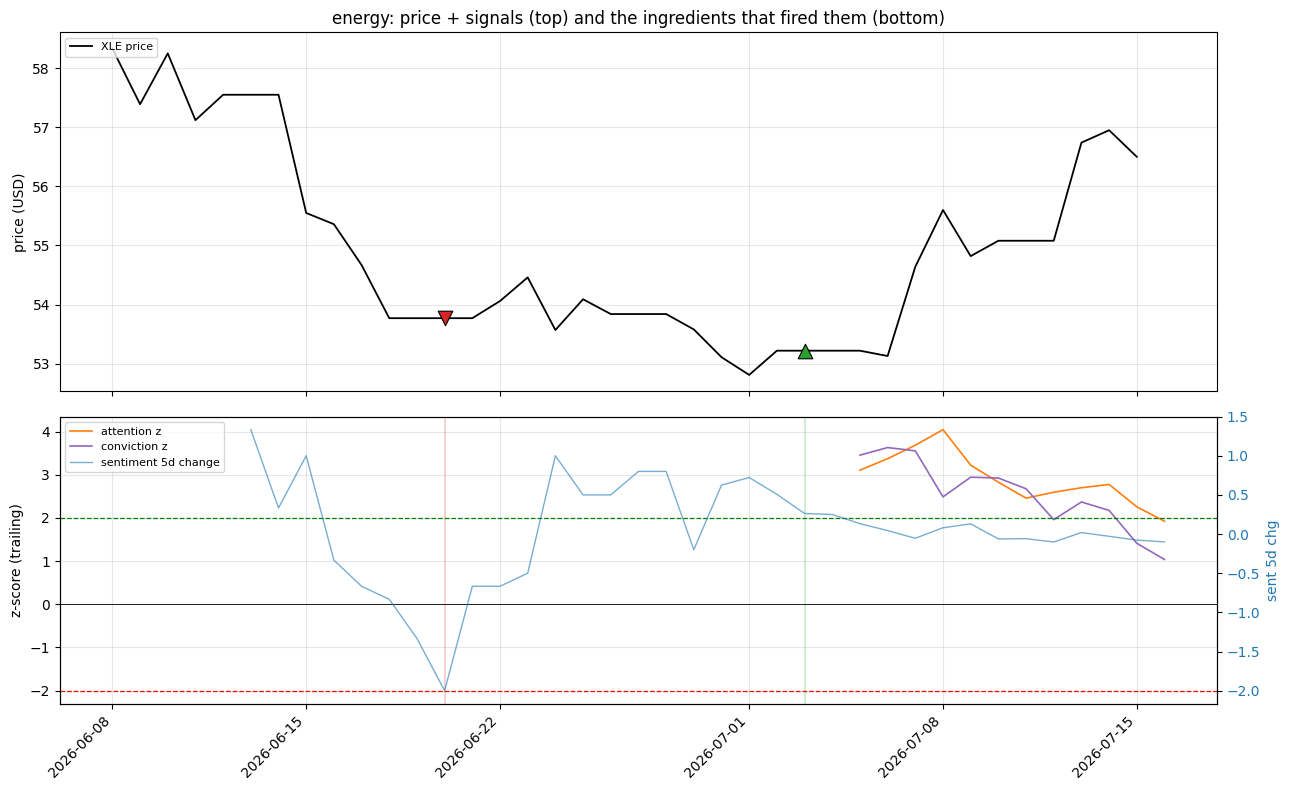

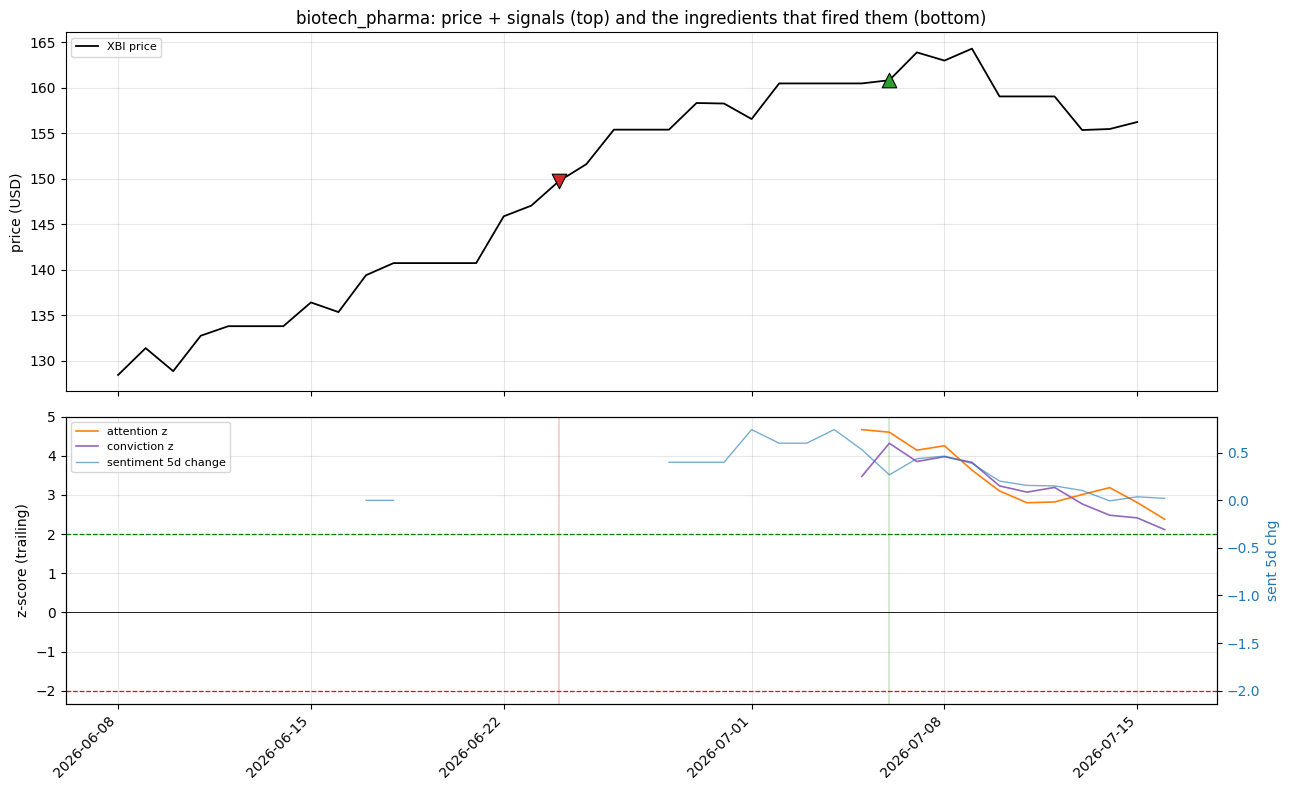

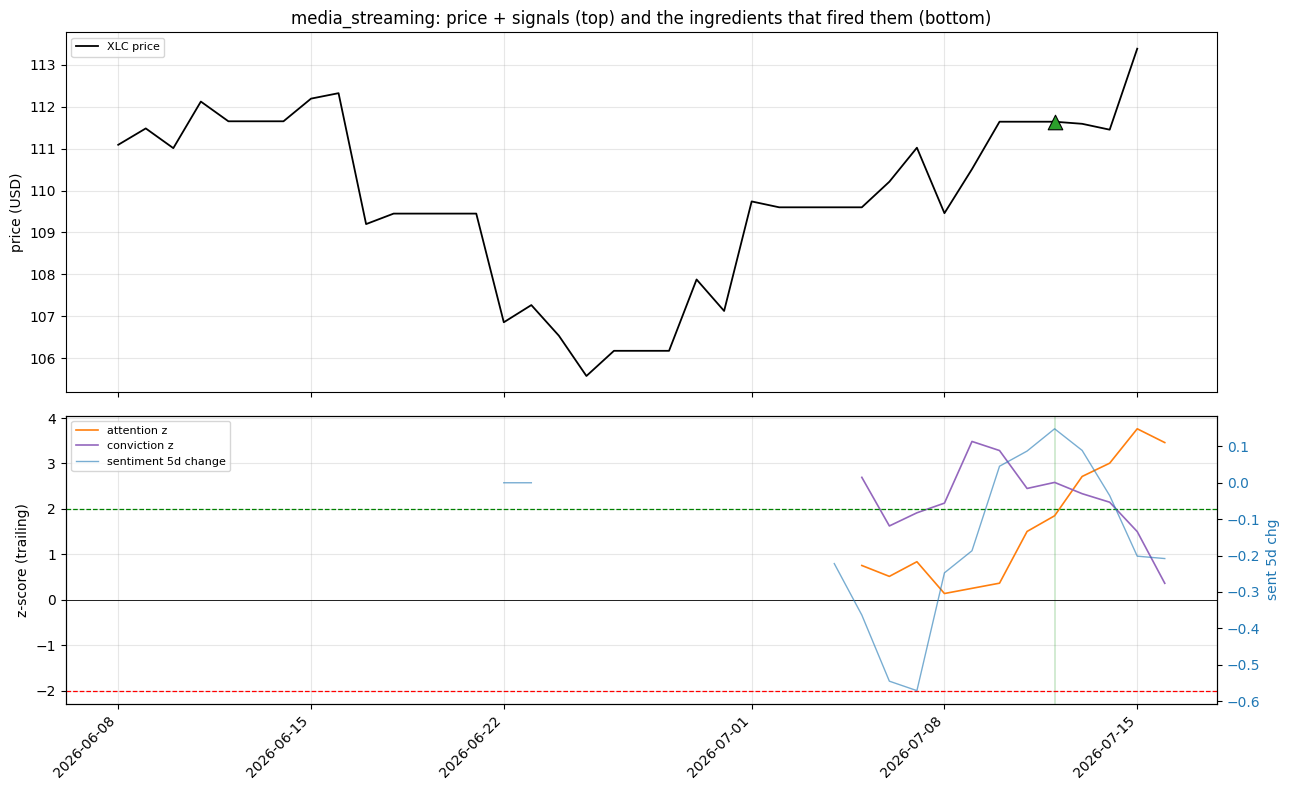

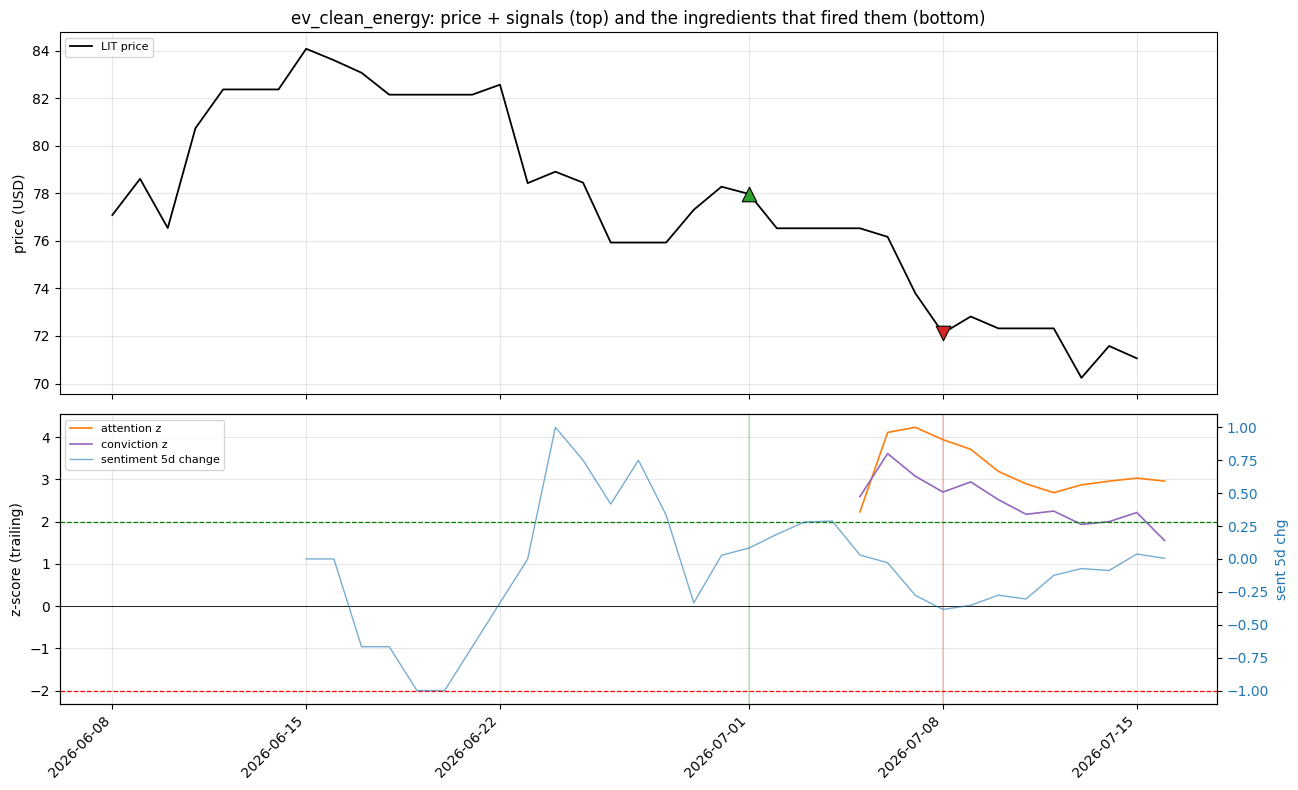

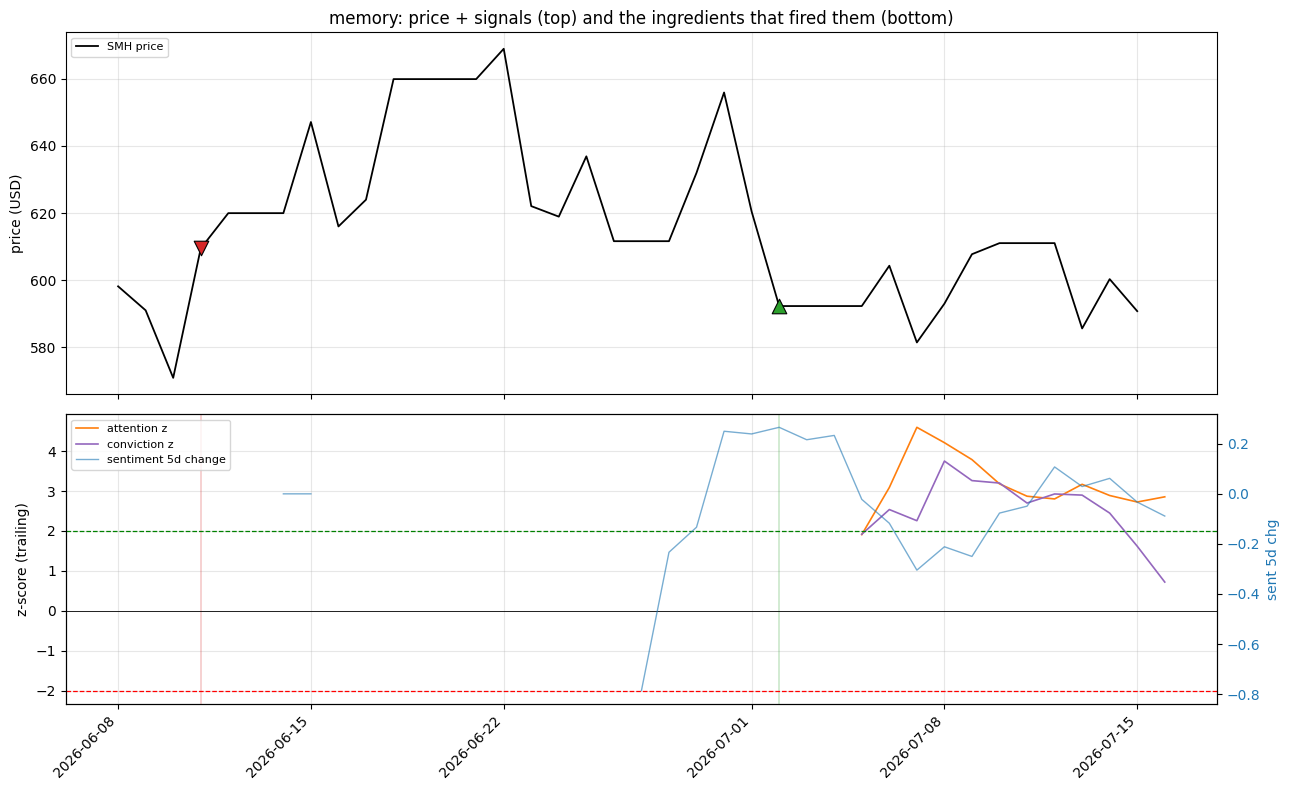

In [6]:
# ==== SIGNAL COMPONENTS over time (notebook 10's exact ingredients) ====
import numpy as np
from src.themes import build_ticker_to_themes

ROLL_C, BASE_C, MIND_C = 7, 84, 28          # same as notebook 10
K_GUIDE = float(os.environ.get('SIG_K', 2.0))

cnt_c = pd.read_parquet(os.path.join(P, 'daily_ticker_counts.parquet'))
cnt_c['date'] = pd.to_datetime(cnt_c['date']); cnt_c = clip_dates(cnt_c, 'date')
lookup_c = build_ticker_to_themes()
cnt_c['themes'] = cnt_c['ticker'].map(lambda t: lookup_c.get(t, []))
td_c = (cnt_c.explode('themes').dropna(subset=['themes'])
        .groupby(['date', 'themes'])['mention_count'].sum().reset_index())
days_c = pd.date_range(cnt_c['date'].min(), cnt_c['date'].max(), freq='D')
wide_c = (td_c.pivot_table(index='date', columns='themes', values='mention_count')
          .reindex(days_c).fillna(0))

def trailing_z_c(frame):
    r = frame.rolling(ROLL_C, min_periods=1).sum()
    mu = r.rolling(BASE_C, min_periods=MIND_C).mean()
    sd = r.rolling(BASE_C, min_periods=MIND_C).std().replace(0, np.nan)
    return (r - mu) / sd

att_c = trailing_z_c(wide_c)

ts_c = pd.read_parquet(os.path.join(P, 'daily_theme_sentiment.parquet'))
ts_c['date'] = pd.to_datetime(ts_c['date']); ts_c = clip_dates(ts_c, 'date')
wn_c = ts_c.pivot_table(index='date', columns='theme', values='n_posts').reindex(days_c).fillna(0)
wb_c = ts_c.pivot_table(index='date', columns='theme', values='net_bullish').reindex(days_c)
pressure_c = (wn_c * wb_c).fillna(0)
conv_c = trailing_z_c(pressure_c)
share_c = (pressure_c.rolling(ROLL_C, min_periods=1).sum()
           / wn_c.rolling(ROLL_C, min_periods=1).sum().replace(0, np.nan))
sent_c = share_c.diff(5)

for theme_name in themes_ranked:
    if theme_name not in conv_c.columns:
        print(f'{theme_name}: no sentiment series in this window - skipped')
        continue
    s = sig_all[sig_all['theme'] == theme_name]
    symbol = s['symbol'].iloc[0]
    px = price_series(prices, symbol)
    if px.empty:
        continue
    fig, (axp, axz) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1.6]})
    axp.plot(px.index, px.values, color='black', linewidth=1.3, label=f'{symbol} price')
    for _, row in s.iterrows():
        d0 = row['action_date']
        if not (px.index.min() <= d0 <= px.index.max()):
            continue
        color = 'tab:green' if row['action'] == 'BUY' else 'tab:red'
        mk = '^' if row['action'] == 'BUY' else 'v'
        axp.scatter([d0], [px.asof(d0)], marker=mk, s=110, color=color,
                    edgecolors='black', linewidths=0.8, zorder=5)
        axz.axvline(d0, color=color, alpha=0.25, linewidth=1.2)
    axp.set_ylabel('price (USD)')
    axp.set_title(f'{theme_name}: price + signals (top) and the ingredients '
                  'that fired them (bottom)')
    axp.grid(True, alpha=0.3); axp.legend(loc='upper left', fontsize=8)

    if theme_name in att_c.columns:
        axz.plot(att_c.index, att_c[theme_name], color='tab:orange',
                 linewidth=1.2, label='attention z')
    axz.plot(conv_c.index, conv_c[theme_name], color='tab:purple',
             linewidth=1.2, label='conviction z')
    axz2 = axz.twinx()
    axz2.plot(sent_c.index, sent_c[theme_name], color='tab:blue',
              linewidth=1.0, alpha=0.6, label='sentiment 5d change')
    axz2.set_ylabel('sent 5d chg', color='tab:blue')
    axz2.tick_params(axis='y', labelcolor='tab:blue')
    axz.axhline(K_GUIDE, color='green', linestyle='--', linewidth=0.9)
    axz.axhline(-K_GUIDE, color='red', linestyle='--', linewidth=0.9)
    axz.axhline(0, color='black', linewidth=0.6)
    axz.set_ylabel('z-score (trailing)')
    h1, l1 = axz.get_legend_handles_labels(); h2, l2 = axz2.get_legend_handles_labels()
    axz.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
    axz.grid(True, alpha=0.3)
    set_date_ticks(axz, X_TICKS)
    fig.tight_layout(); plt.show()

## Opportunity gap: strong themes you CANNOT trade yet

Grey bars = themes with an approved instrument (the tradeable book).
Orange bars = tracked-only themes: no approved instrument (crypto,
cannabis, small caps) and auto-promoted emerging themes. An orange bar to
the RIGHT of the dashed line (the tradeable median) is retail conviction
the desk currently has no way to express - the shortlist for requesting a
new instrument on the approved list.

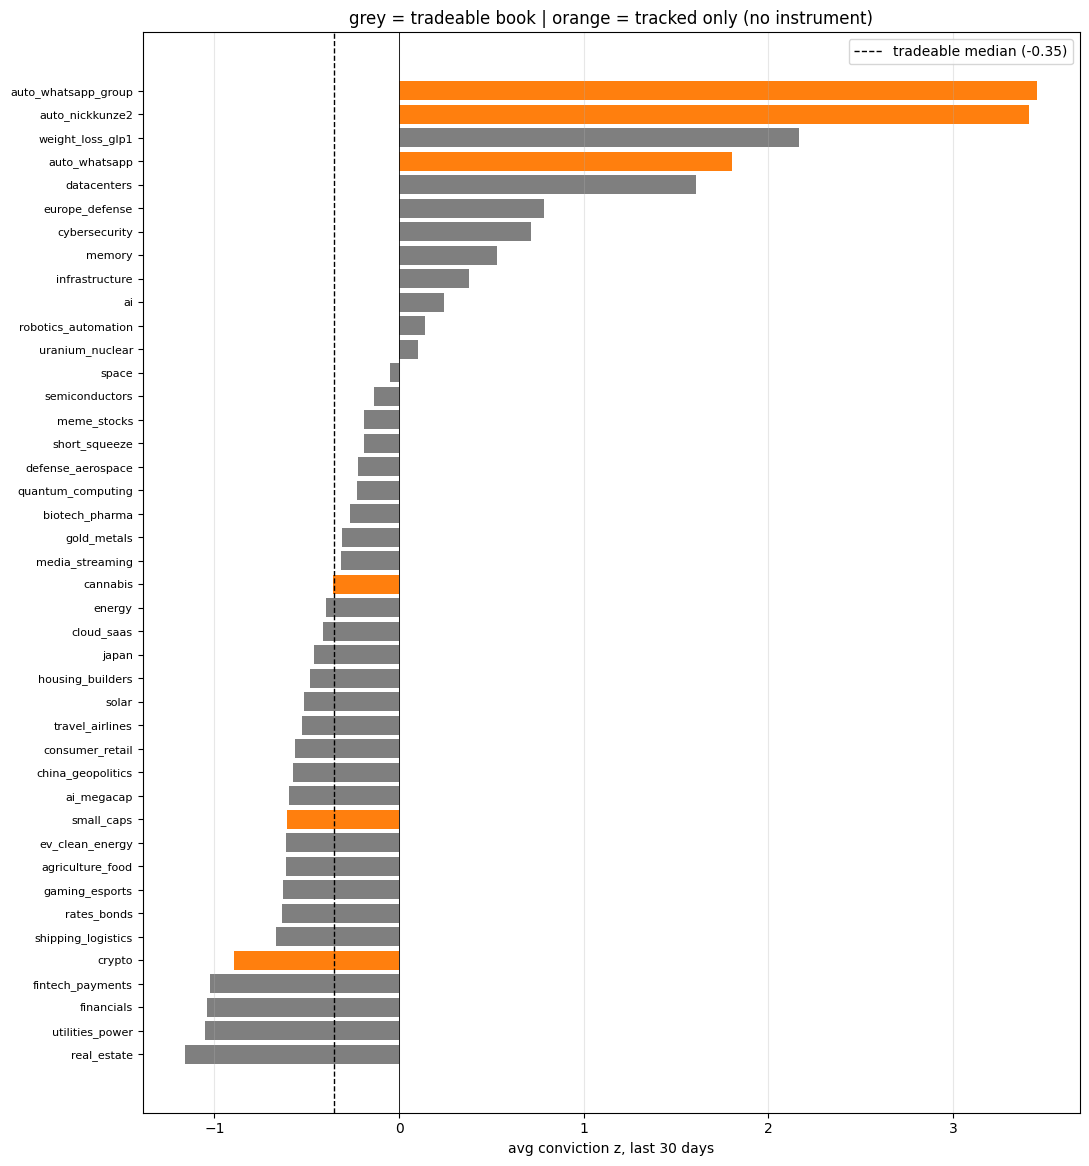

tracked-only themes ABOVE the tradeable median - consider requesting an instrument:
  auto_whatsapp_group          avg conviction z +3.46
  auto_nickkunze2              avg conviction z +3.41
  auto_whatsapp                avg conviction z +1.80


In [7]:
# ==== OPPORTUNITY GAP: conviction of tradeable vs tracked-only themes ====
GAP_DAYS = 30     # 'recent' = average conviction over the last N days

conv_g = pd.read_parquet(os.path.join(P, 'daily_theme_conviction.parquet'))
conv_g['date'] = pd.to_datetime(conv_g['date'])
conv_g = clip_dates(conv_g, 'date')
if len(conv_g):
    recent_g = conv_g[conv_g['date'] >= conv_g['date'].max()
                      - pd.Timedelta(days=GAP_DAYS)]
    score_g = recent_g.groupby('theme')['conviction_z'].mean().sort_values()

    from src.themes import THEME_ETFS as _ANCHORS
    tradeable_g = score_g.index.isin(_ANCHORS)
    med_g = score_g[tradeable_g].median() if tradeable_g.any() else 0.0

    fig, ax = plt.subplots(figsize=(11, max(5, 0.28 * len(score_g))))
    ax.barh(range(len(score_g)), score_g.values,
            color=['tab:gray' if t else 'tab:orange' for t in tradeable_g])
    ax.set_yticks(range(len(score_g)))
    ax.set_yticklabels(score_g.index, fontsize=8)
    ax.axvline(med_g, color='black', linestyle='--', linewidth=1,
               label=f'tradeable median ({med_g:+.2f})')
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_xlabel(f'avg conviction z, last {GAP_DAYS} days')
    ax.set_title('grey = tradeable book | orange = tracked only (no instrument)')
    ax.legend(); ax.grid(True, alpha=0.3, axis='x')
    fig.tight_layout(); plt.show()

    gap_list = score_g[(~tradeable_g) & (score_g > med_g)]
    if len(gap_list):
        print('tracked-only themes ABOVE the tradeable median - consider '
              'requesting an instrument:')
        for t, v in gap_list.sort_values(ascending=False).items():
            print(f'  {t:<28} avg conviction z {v:+.2f}')
    else:
        print('no tracked-only theme currently out-scores the tradeable book.')
else:
    print('no conviction data in this window')